In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

# the notebook will automatically update without you having to restart it.
%load_ext autoreload
%autoreload 2

# libraries
from src.mdwater.nonbonded import compute_lj_potential, compute_coulomb_potential
from src.mdwater.velocity_verlet import velocity_verlet
from src.mdwater.force_field import SPCForceField
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

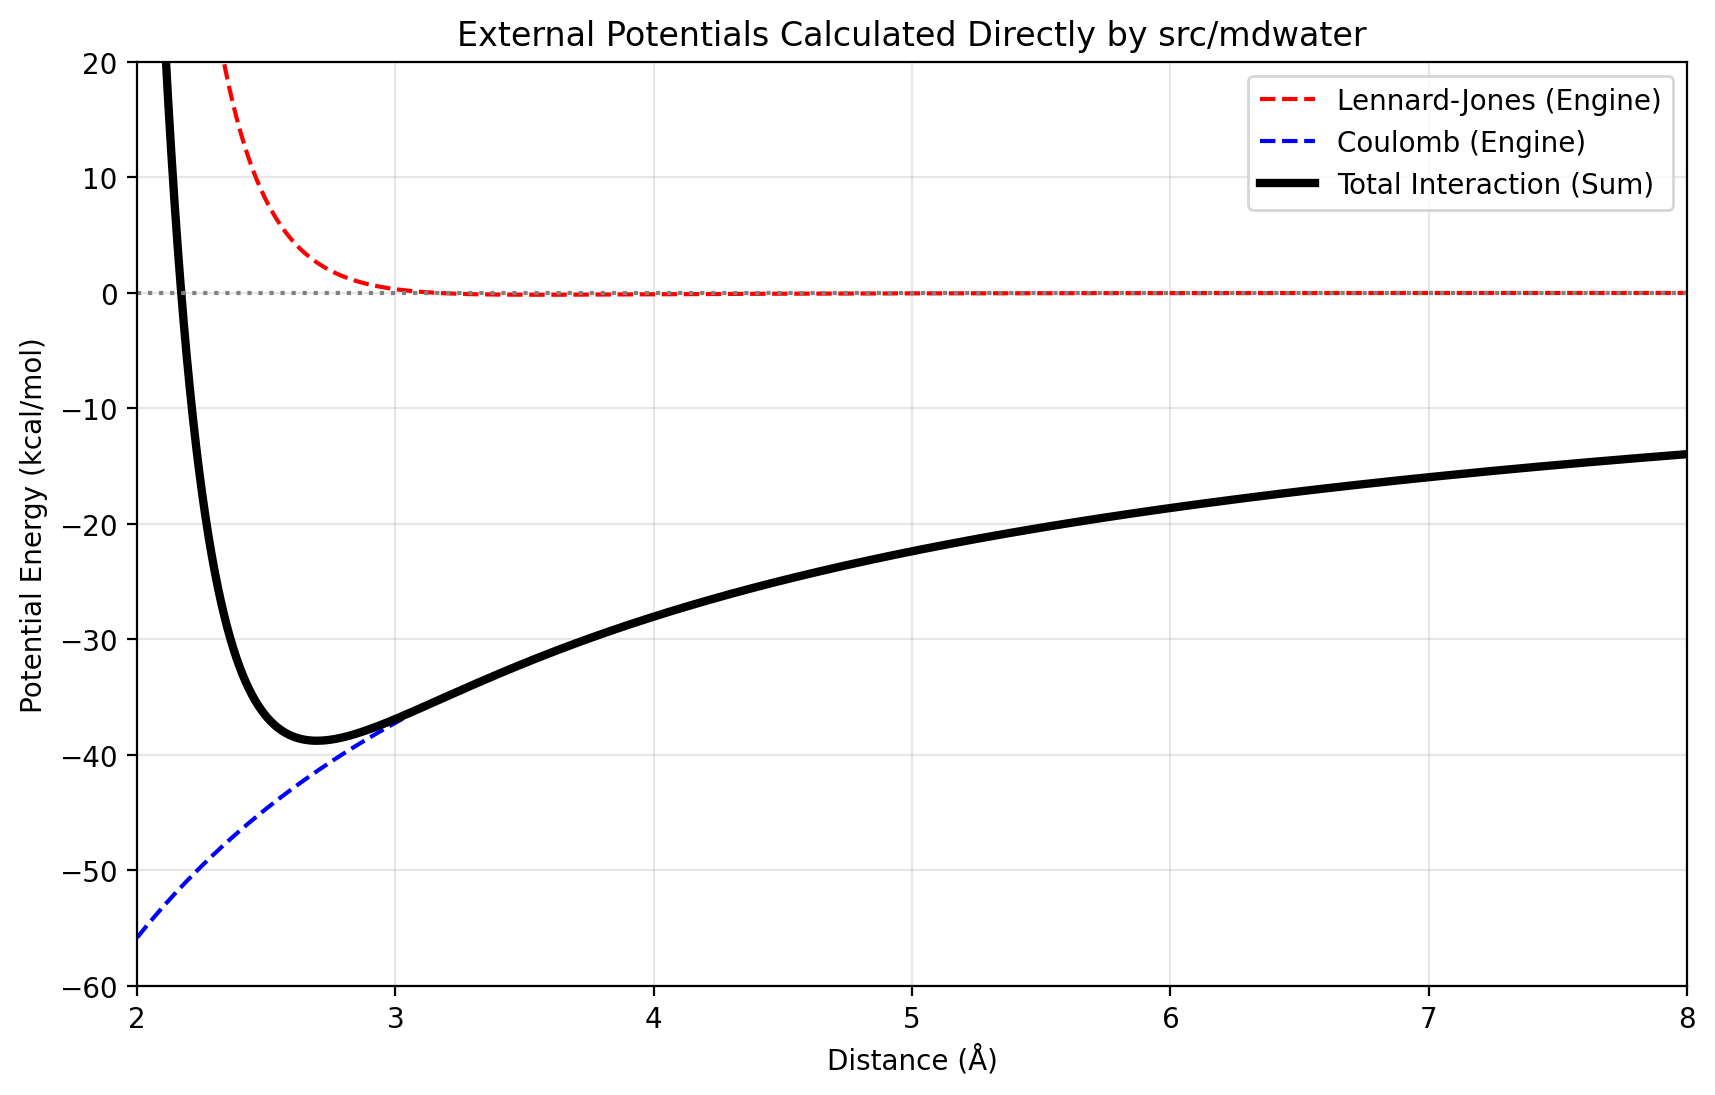

In [2]:
# Constants
A_LJ = 629400.0
B_LJ = 625.5
C_COULOMB = 332.06375

# Distances to test (from 2.0 Å to 8.0 Å)
r_values = np.linspace(2.0, 8.0, 500)

# Arrays to store the energies your engine calculates
v_lj_engine = np.zeros(len(r_values))
v_coulomb_engine = np.zeros(len(r_values))
v_total = np.zeros(len(r_values))

# Dummy topology lists for our 2-atom tests
pair_list = np.array([[0, 1]])
charges = np.array([-0.82, 0.41])  # Oxygen and Hydrogen

for i, r in enumerate(r_values):
    # 1. Build the 3D dummy universe
    q_dummy = np.array([
        [0.0, 0.0, 0.0],  # Atom 0 at the origin
        [r, 0.0, 0.0]     # Atom 1 moving along the X-axis
    ])
    
    # 2. Ask YOUR engine for the Lennard-Jones Energy (Pretending both are Oxygens)
    v_lj_engine[i] = compute_lj_potential(q_dummy, pair_list, A_LJ, B_LJ)
    
    # 3. Ask YOUR engine for the Coulomb Energy (Oxygen and Hydrogen)
    v_coulomb_engine[i] = compute_coulomb_potential(q_dummy, pair_list, charges, C_COULOMB)
    
    # 4. Total Interaction Energy
    v_total[i] = v_lj_engine[i] + v_coulomb_engine[i]

# ==========================================
# PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(r_values, v_lj_engine, color='red', linestyle='--', label="Lennard-Jones (Engine)")
plt.plot(r_values, v_coulomb_engine, color='blue', linestyle='--', label="Coulomb (Engine)")
plt.plot(r_values, v_total, color='black', linewidth=3, label="Total Interaction (Sum)")

# Add a line at Energy = 0
plt.axhline(0, color='gray', linestyle=':')

# Zoom in so we can actually see the "well"
plt.ylim(-60, 20) 
plt.xlim(2.0, 8.0)

plt.title("External Potentials Calculated Directly by src/mdwater")
plt.xlabel("Distance (Å)")
plt.ylabel("Potential Energy (kcal/mol)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

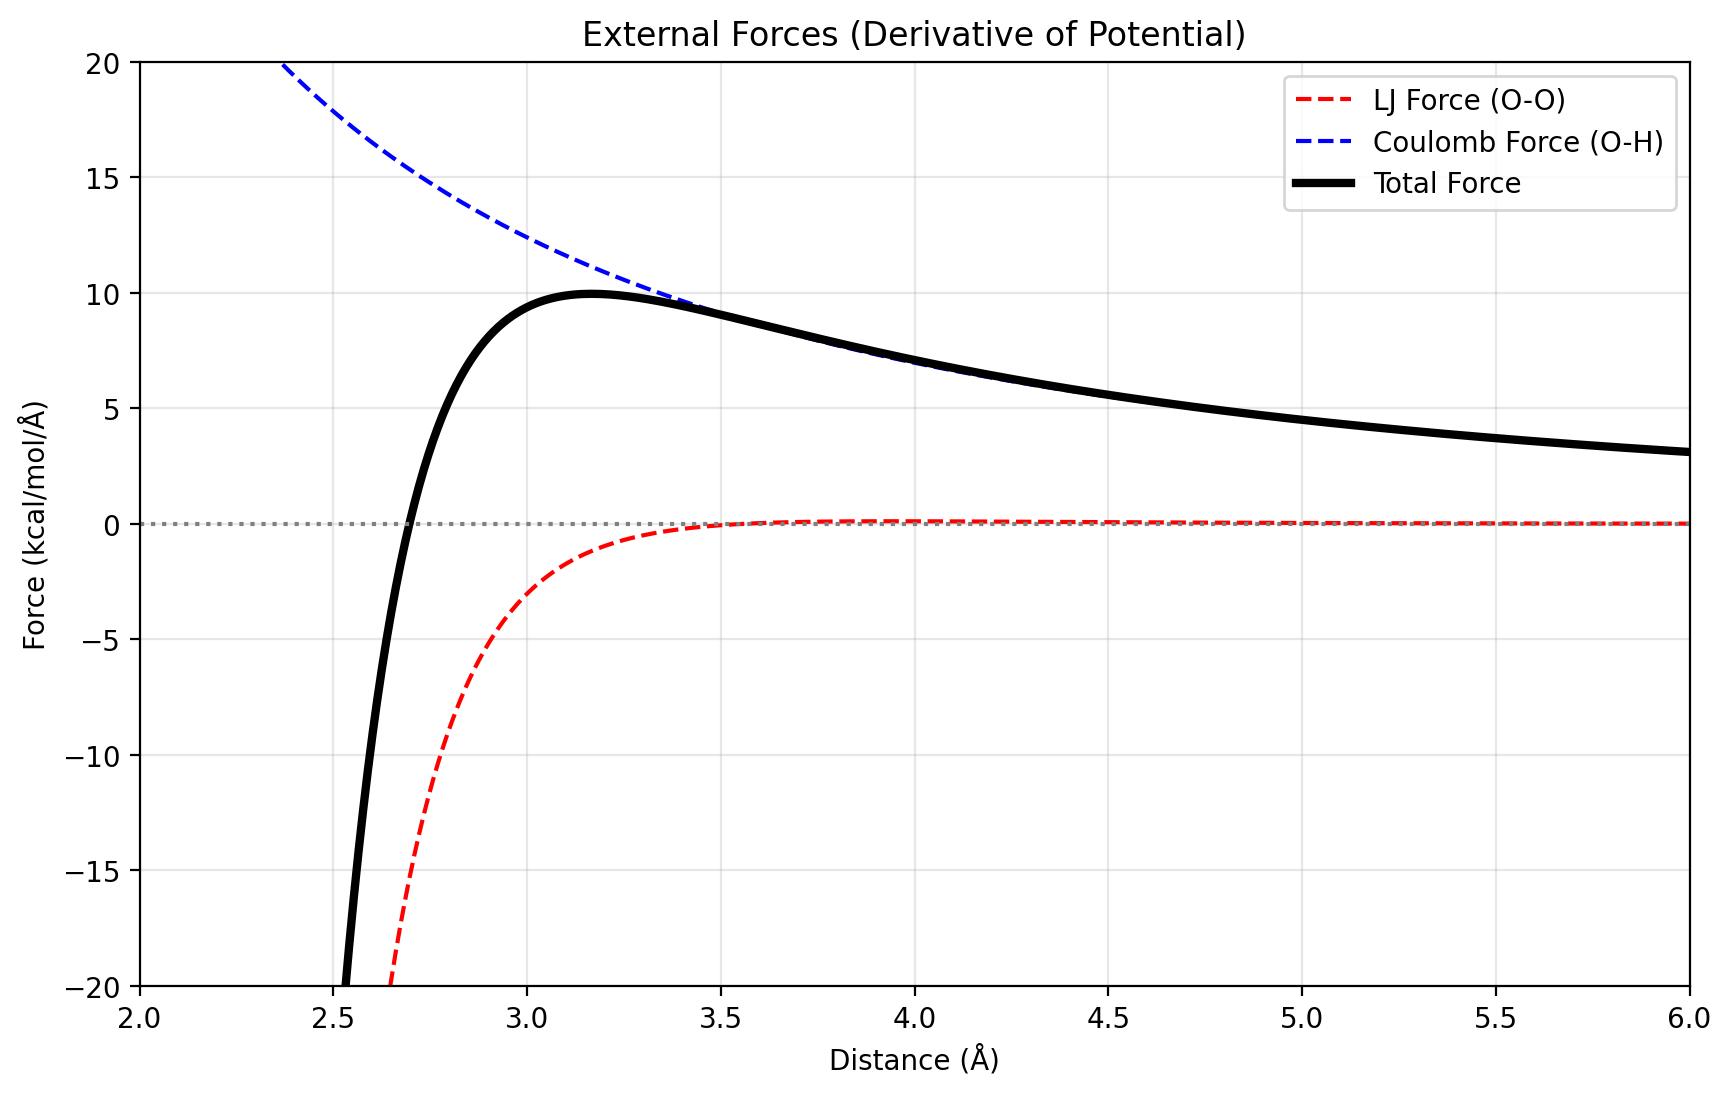

In [3]:
from src.mdwater.nonbonded import compute_lj_forces, compute_coulomb_forces

f_lj_engine = np.zeros(len(r_values))
f_coulomb_engine = np.zeros(len(r_values))
f_total = np.zeros(len(r_values))

for i, r in enumerate(r_values):
    q_dummy = np.array([[0.0, 0.0, 0.0], [r, 0.0, 0.0]])
    
    # Calculate Forces (Note: we take the X-component of atom 0)
    f_lj = compute_lj_forces(q_dummy, pair_list, A_LJ, B_LJ)
    f_lj_engine[i] = f_lj[0, 0] 
    
    f_coulomb = compute_coulomb_forces(q_dummy, pair_list, charges, C_COULOMB)
    f_coulomb_engine[i] = f_coulomb[0, 0]
    
    f_total[i] = f_lj_engine[i] + f_coulomb_engine[i]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(r_values, f_lj_engine, color='red', linestyle='--', label="LJ Force (O-O)")
plt.plot(r_values, f_coulomb_engine, color='blue', linestyle='--', label="Coulomb Force (O-H)")
plt.plot(r_values, f_total, color='black', linewidth=3, label="Total Force")

plt.axhline(0, color='gray', linestyle=':')
plt.ylim(-20, 20) # Zoom in to see the crossing
plt.xlim(2.0, 6.0)

plt.title("External Forces (Derivative of Potential)")
plt.xlabel("Distance (Å)")
plt.ylabel("Force (kcal/mol/Å)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:

# compute the zero crossing of total force
sign_changes = np.where(np.sign(f_total[:-1]) != np.sign(f_total[1:]))[0]
if sign_changes.size > 0:
    idx = sign_changes[0]
    # linear interpolation between r[idx] and r[idx+1]
    r1, r2 = r_values[idx], r_values[idx+1]
    f1, f2 = f_total[idx], f_total[idx+1]
    r_zero = r1 - f1 * (r2 - r1) / (f2 - f1)
    print(f"total force zero crossing near r={r_zero:.6f} Å")
else:
    print("no zero crossing found in force data")


total force zero crossing near r=2.696251 Å


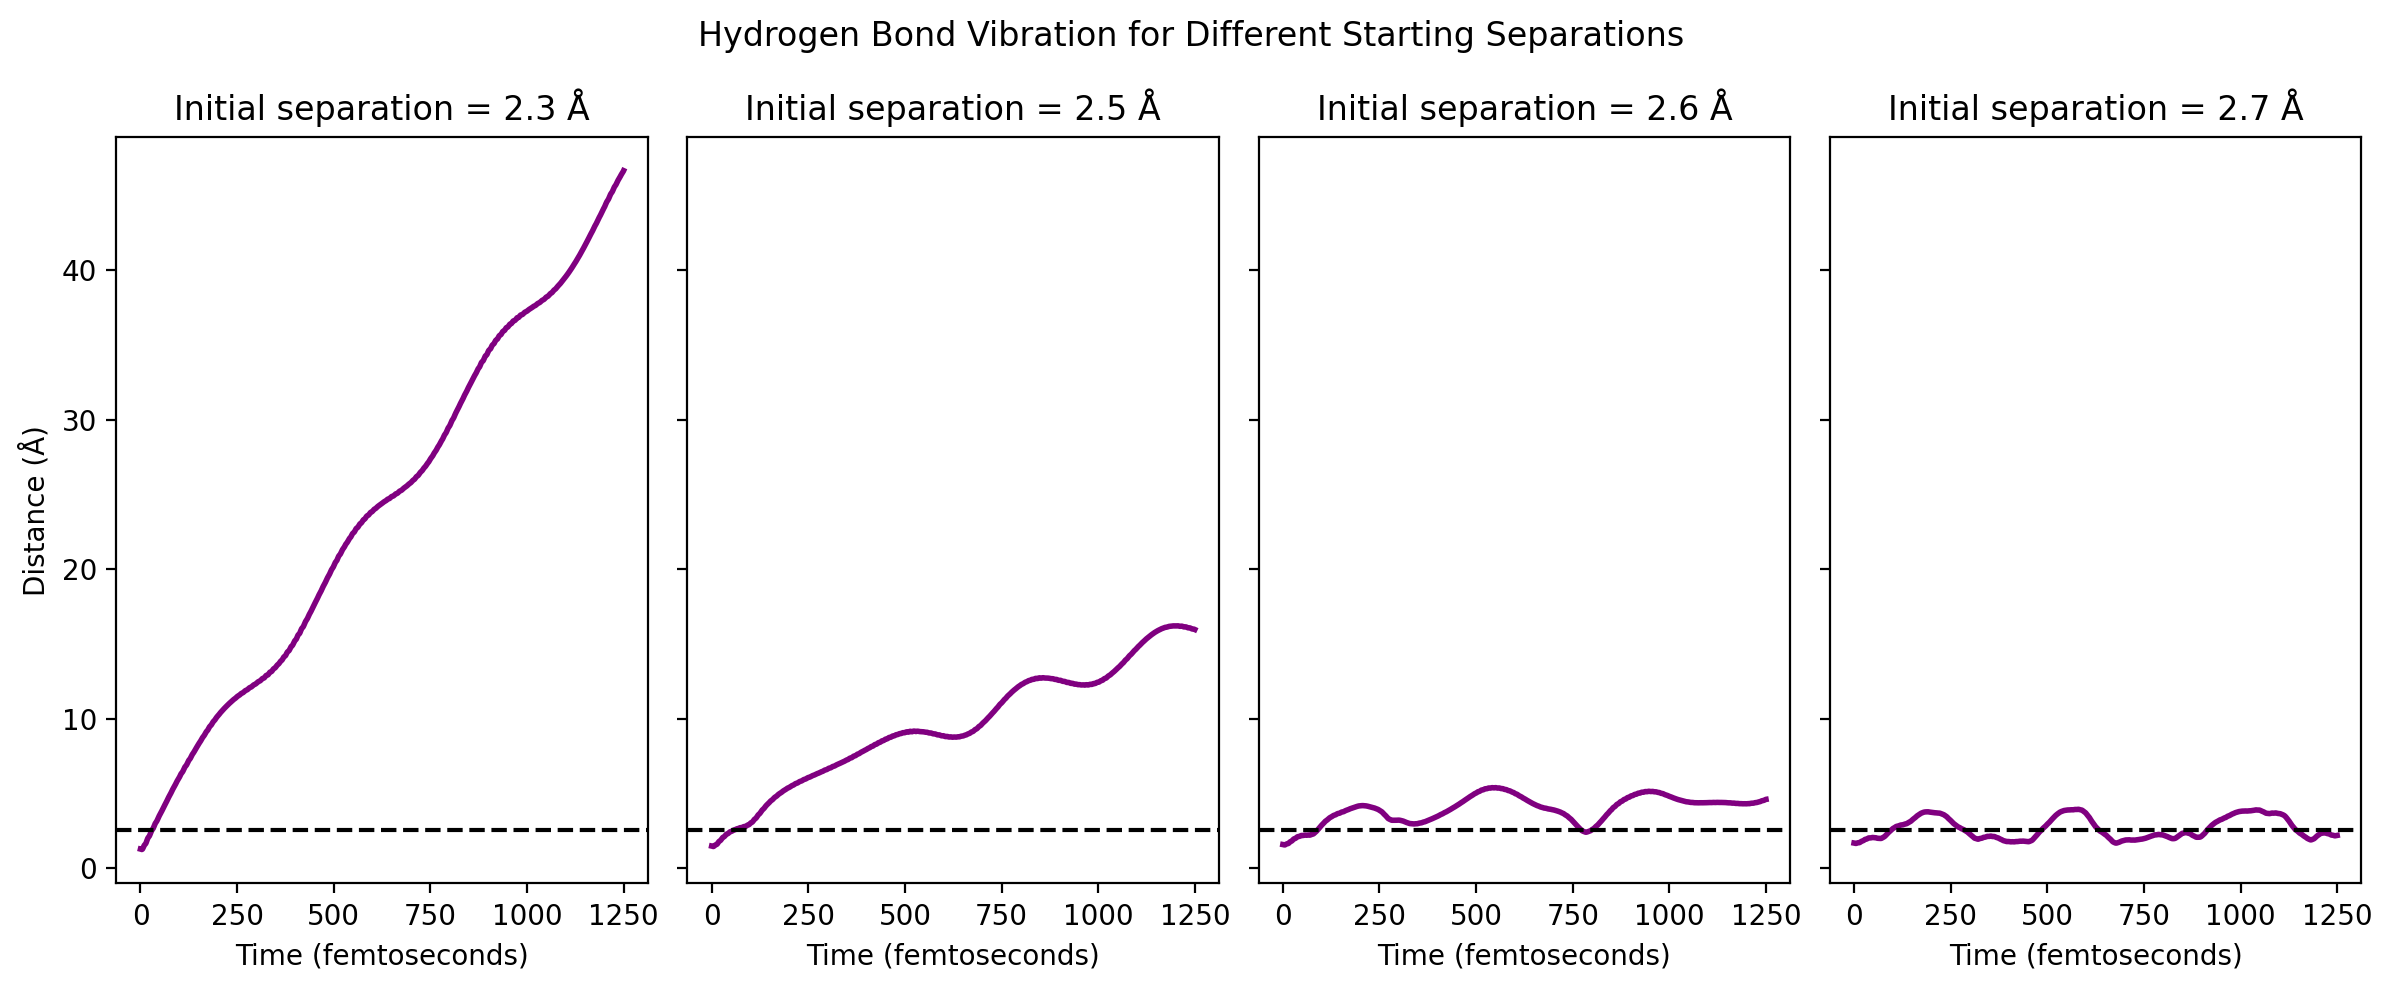

In [8]:
# helper function: run two-molecule vibration simulation and return time and O–H distance

def simulate_hbond(sep, dt=0.25/48.88, num_steps=5000):
    MASS_O = 15.999
    MASS_H = 1.008
    masses = np.array([MASS_O, MASS_H, MASS_H, MASS_O, MASS_H, MASS_H])
    charges = np.array([-0.82, 0.41, 0.41, -0.82, 0.41, 0.41])

    bond_list = np.array([[0, 1], [0, 2], [3, 4], [3, 5]])
    angle_list = np.array([[0, 1, 2], [3, 4, 5]])
    lj_pair_list = np.array([[0, 3]])
    coulomb_pair_list = np.array([
        [0, 3], [0, 4], [0, 5],
        [1, 3], [1, 4], [1, 5],
        [2, 3], [2, 4], [2, 5]
    ])

    ff = SPCForceField(bond_list, angle_list, lj_pair_list, coulomb_pair_list, charges)

    REQ = 1.0
    THETA_EQ = np.deg2rad(109.47)
    mol1 = np.array([
        [0.0, 0.0, 0.0],
        [REQ, 0.0, 0.0],
        [REQ * np.cos(THETA_EQ), REQ * np.sin(THETA_EQ), 0.0]
    ])
    mol2 = mol1.copy()
    mol2[:, 0] += sep

    q0 = np.vstack((mol1, mol2))
    p0 = np.zeros_like(q0)

    traj_q, traj_p = velocity_verlet(q0, p0, masses, ff.get_forces, dt, num_steps)

    # O–H distance between atom 3 (O of molecule2) and atom1 (H of molecule1)
    h_bond = [np.linalg.norm(q[3] - q[1]) for q in traj_q]
    time = np.arange(num_steps + 1) * 0.25
    return time, np.array(h_bond)


# run two different initial separations and plot side-by-side
distances = [2.3, 2.5, 2.6, 2.7]
results = [simulate_hbond(d) for d in distances]

fig, axes = plt.subplots(1, len(distances), figsize=(12, 5), sharey=True)
for ax, sep, (time_axis, h_bond) in zip(axes, distances, results):
    ax.plot(time_axis, h_bond, color='purple', linewidth=2)
    ax.axhline(2.6, color='black', linestyle='--')
    ax.set_title(f"Initial separation = {sep:.1f} Å")
    ax.set_xlabel("Time (femtoseconds)")

axes[0].set_ylabel("Distance (Å)")
fig.suptitle("Hydrogen Bond Vibration for Different Starting Separations")
fig.tight_layout()
plt.show()

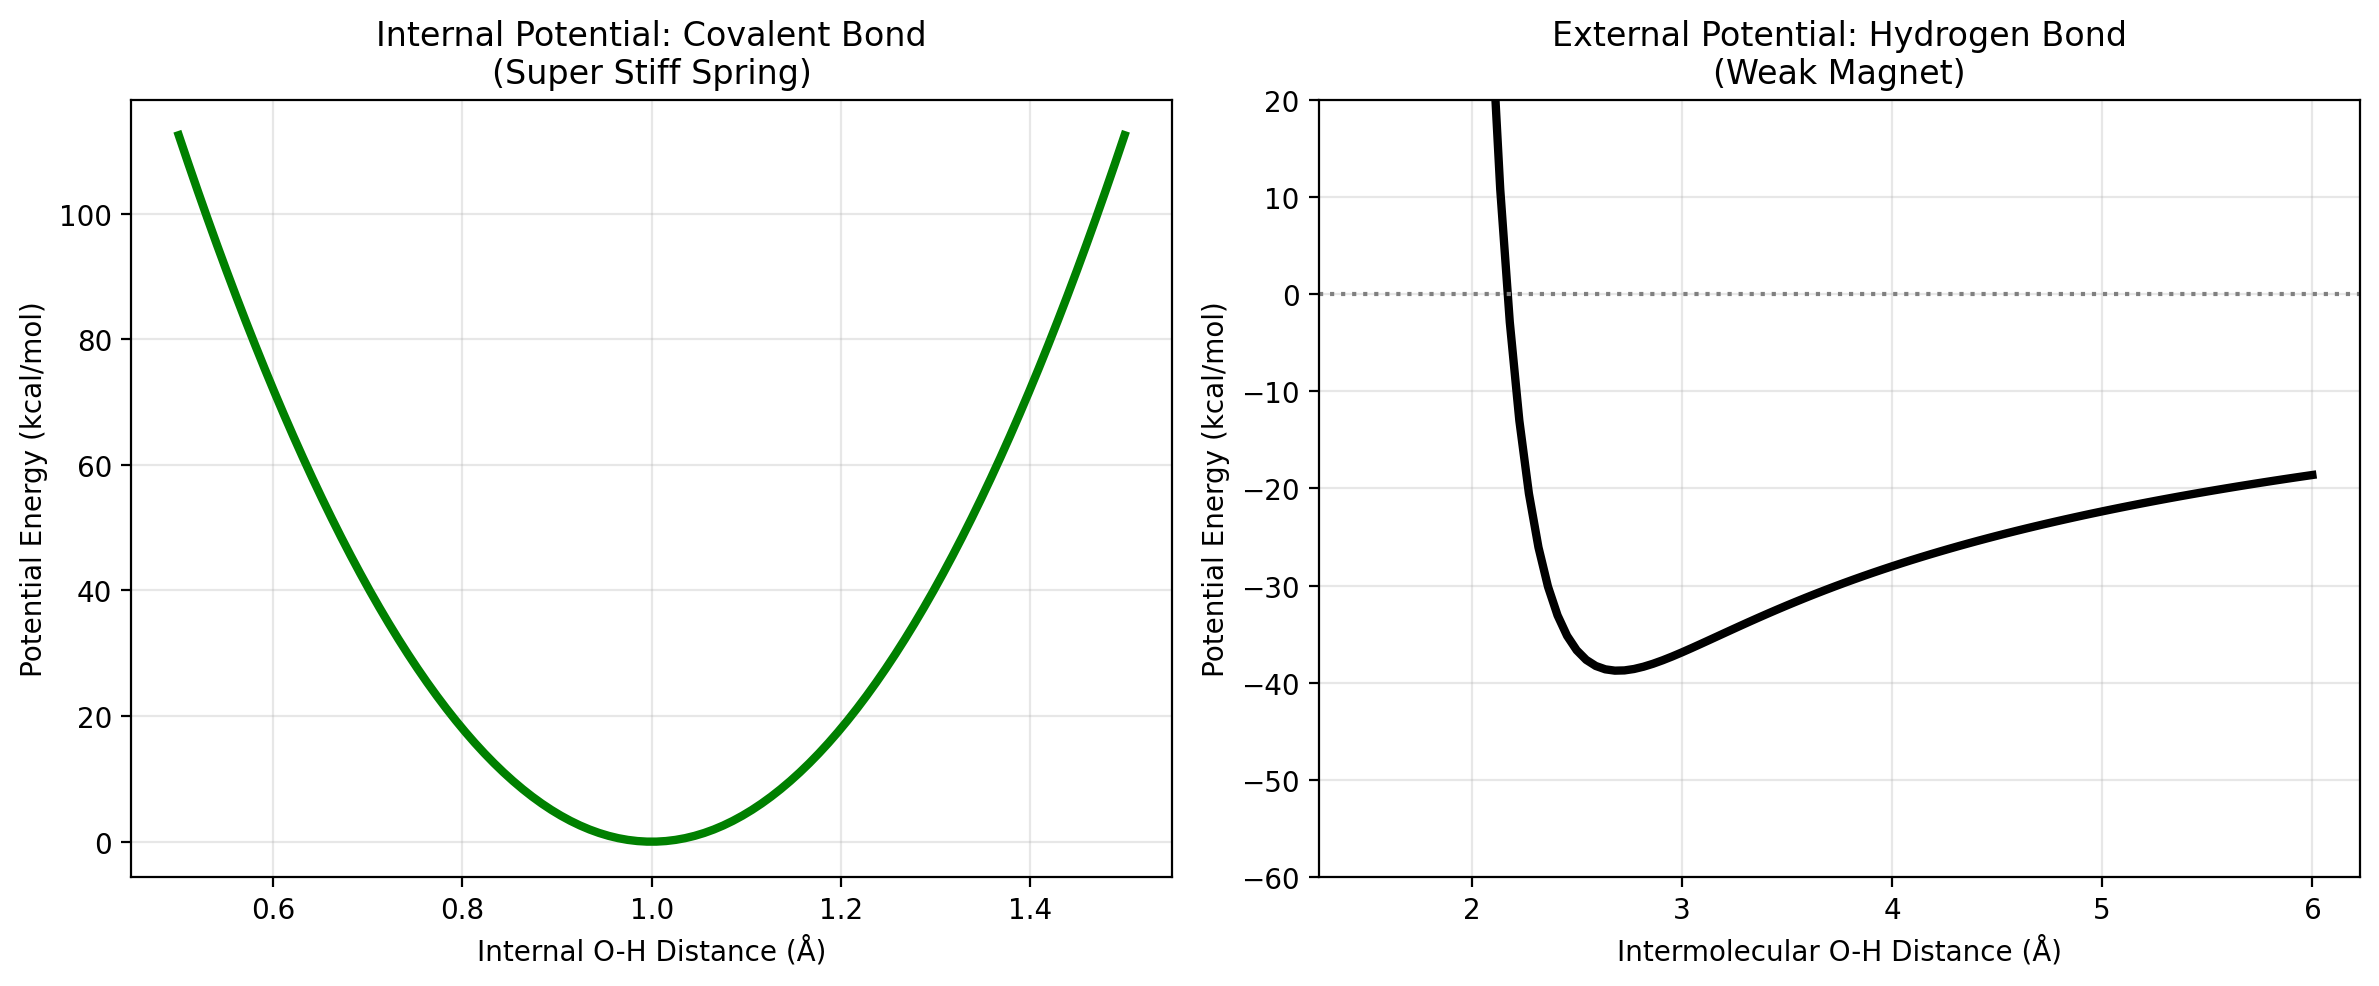

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. INTERNAL POTENTIAL (Covalent O-H Bond)
# Modeled as a harmonic spring (Hooke's Law)
r_internal = np.linspace(0.5, 1.5, 100)
K_BOND = 450.0  # Spring constant (kcal/mol/Å^2)
R_EQ = 1.0      # Equilibrium bond length (Å)
V_internal = K_BOND * (r_internal - R_EQ)**2

# 2. EXTERNAL POTENTIAL (Hydrogen Bond O-H)
# We will use the exact data from our previous sum (LJ + Coulomb)
r_external = np.linspace(1.5, 6.0, 100)
A_LJ = 629400.0
B_LJ = 625.5
C_COULOMB = 332.06375
q_O = -0.82
q_H = 0.41

V_lj = (A_LJ / r_external**12) - (B_LJ / r_external**6)
V_coulomb = C_COULOMB * (q_O * q_H) / r_external
V_external_total = V_lj + V_coulomb

# ==========================================
# PLOT THEM SIDE-BY-SIDE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Internal (Spring)
ax1.plot(r_internal, V_internal, color='green', linewidth=3)
ax1.set_title("Internal Potential: Covalent Bond\n(Super Stiff Spring)")
ax1.set_xlabel("Internal O-H Distance (Å)")
ax1.set_ylabel("Potential Energy (kcal/mol)")
ax1.grid(alpha=0.3)

# Plot External (Magnet)
ax2.plot(r_external, V_external_total, color='black', linewidth=3)
ax2.axhline(0, color='gray', linestyle=':')
ax2.set_title("External Potential: Hydrogen Bond\n(Weak Magnet)")
ax2.set_xlabel("Intermolecular O-H Distance (Å)")
ax2.set_ylabel("Potential Energy (kcal/mol)")
ax2.set_ylim(-60, 20)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()